# MountainCar Q-Learning
Tabular Q-learning (with **state-space discretisation**) on the **MountainCar-v0** Gymnasium environment.

## Environment Overview
| Property | Value |
|---|---|
| Observation | `[position, velocity]` — both **continuous** |
| Position range | −1.2 to 0.6 |
| Velocity range | −0.07 to 0.07 |
| Actions | 0 = push left, 1 = no push, 2 = push right |
| Goal | Reach position ≥ 0.5 (top of right hill) |
| Challenge | The car is underpowered — it **must build momentum** by swinging back and forth |

Because the state space is continuous, we **discretise** it into a 20 × 20 grid before applying tabular Q-learning.

## Install & Import Dependencies

In [11]:
# Install gymnasium if not already present
!pip install gymnasium matplotlib seaborn numpy imageio

In [12]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import random
import seaborn as sn
import matplotlib.pyplot as plt
from IPython.display import Image
import imageio.v2 as imageio
import numpy as np

## Q-Learning Background

After observing a transition $(s_t, a_t, r_{t+1}, s_{t+1})$, the update rule is:

$$Q(s_t, a_t) \leftarrow (1 - \alpha)\, Q(s_t, a_t) + \alpha \Big( r_{t+1} + \gamma \max_{a'} Q(s_{t+1}, a') \Big)$$

- **α** (learning rate): step size for Q-value updates  
- **γ** (discount factor): weight placed on future rewards  
- **ε-greedy**: with probability ε pick a random action (explore), otherwise pick $\arg\max_a Q(s,a)$ (exploit)  
- **ε decays** exponentially so the agent transitions from exploration to exploitation

## Hyperparameters

In [13]:
# ── Hyperparameters ──────────────────────────────────────────────────────────
LEARNING_RATE   = 0.1       # α
DISCOUNT_FACTOR = 0.95      # γ
EPSILON         = 1.0       # starting exploration rate
EPSILON_DECAY   = 0.9995    # multiplicative decay per episode
EPSILON_MIN     = 0.01      # floor for ε
N_EPISODES      = 50000    # total training episodes
MAX_STEPS       = 120       # max steps per episode
TABLE_SIZE      = (20, 20)  # discretisation grid: position × velocity

print("Hyperparameters set.")

Hyperparameters set.


## State-Space Discretisation

MountainCar has a **continuous** observation space, so we map each `(position, velocity)` pair into an integer index on a 20 × 20 grid.

```
window_size = (obs_high − obs_low) / table_size
discrete_index = (obs − obs_low) / window_size   →   (int, int)
```

This gives a Q-table of shape `(20, 20, 3)` — one entry per grid cell per action.

In [14]:
env = gym.make("MountainCar-v0")
env.reset()

window_size = (
    env.observation_space.high - env.observation_space.low
) / np.array(TABLE_SIZE)

def get_discrete_state(state: np.ndarray) -> tuple[int, int]:
    """Map a continuous observation to a discrete grid index."""
    index = (state - env.observation_space.low) / window_size
    return tuple(index.astype(int))

# Q-table: (pos_bins, vel_bins, actions)
q_table = np.random.uniform(
    low=0, high=1,
    size=(TABLE_SIZE[0], TABLE_SIZE[1], env.action_space.n)
)

print(f"Q-table shape   : {q_table.shape}")
print(f"Window size     : {window_size}")
print(f"Obs space low   : {env.observation_space.low}")
print(f"Obs space high  : {env.observation_space.high}")
print(f"Action space    : {env.action_space}  (0=left, 1=none, 2=right)")

Q-table shape   : (20, 20, 3)
Window size     : [0.09  0.007]
Obs space low   : [-1.2  -0.07]
Obs space high  : [0.6  0.07]
Action space    : Discrete(3)  (0=left, 1=none, 2=right)


## Training Loop

For each episode:
1. Reset the environment and discretise the initial state.
2. Choose an action via **ε-greedy** policy.
3. Execute the action, observe `(new_state, reward, done)`.
4. Discretise the new state.
5. Apply the **Q-learning update**.
6. Decay ε after the episode ends.

In [15]:
epsilon     = EPSILON
reward_list: list[float] = []

for episode in range(N_EPISODES):
    step            = 0
    state           = env.reset()[0]
    discrete_state  = get_discrete_state(state)
    done            = False
    total_reward    = 0.0

    while not done and step < MAX_STEPS:
        # ε-greedy action selection
        if random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()                  # explore
        else:
            action = int(np.argmax(q_table[discrete_state]))    # exploit

        new_state, reward, done, _, _ = env.step(action)
        total_reward      += reward
        new_discrete_state = get_discrete_state(new_state)

        if not done:
            # Standard Q-learning update
            best_future_q = np.max(q_table[new_discrete_state])
            current_q     = q_table[discrete_state][action]
            new_q = (1 - LEARNING_RATE) * current_q + LEARNING_RATE * (
                reward + DISCOUNT_FACTOR * best_future_q
            )
            q_table[discrete_state][action] = new_q

        elif new_state[0] >= env.unwrapped.goal_position:
            q_table[discrete_state][action] = 0    # terminal — no future reward
            done = True
            print(f"  ✓ Goal reached — episode {episode:>5d}, step {step}")

        step           += 1
        discrete_state  = new_discrete_state

    reward_list.append(total_reward)
    epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)

env.close()
print(f"\nTraining complete. Final ε = {epsilon:.4f}")

  ✓ Goal reached — episode  8912, step 119
  ✓ Goal reached — episode  9285, step 115
  ✓ Goal reached — episode  9286, step 118
  ✓ Goal reached — episode  9454, step 113
  ✓ Goal reached — episode  9612, step 117
  ✓ Goal reached — episode  9624, step 117
  ✓ Goal reached — episode  9698, step 118
  ✓ Goal reached — episode  9704, step 118
  ✓ Goal reached — episode  9708, step 119
  ✓ Goal reached — episode  9715, step 118
  ✓ Goal reached — episode  9729, step 119
  ✓ Goal reached — episode  9735, step 116
  ✓ Goal reached — episode  9738, step 119
  ✓ Goal reached — episode  9748, step 119
  ✓ Goal reached — episode  9749, step 119
  ✓ Goal reached — episode  9753, step 117
  ✓ Goal reached — episode  9755, step 117
  ✓ Goal reached — episode  9756, step 116
  ✓ Goal reached — episode  9757, step 114
  ✓ Goal reached — episode  9768, step 114
  ✓ Goal reached — episode  9770, step 113
  ✓ Goal reached — episode  9776, step 116
  ✓ Goal reached — episode  9780, step 114
  ✓ Goal re

## Reward Curve
A rising (less-negative) reward curve shows the agent learning to reach the goal faster.

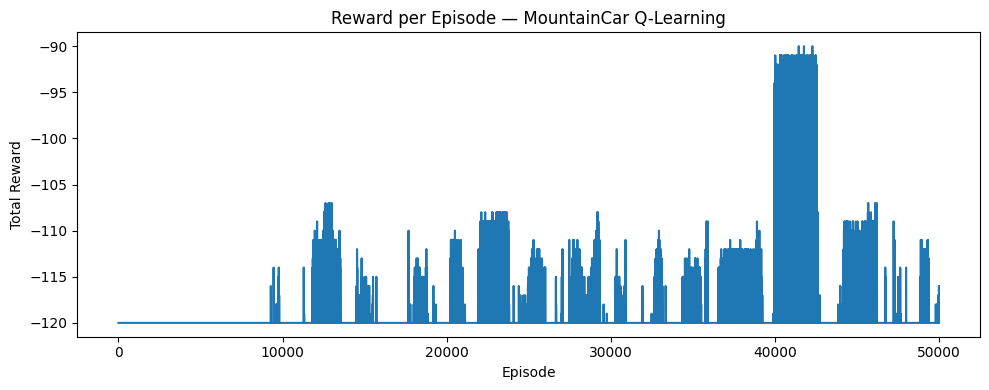

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
sn.lineplot(reward_list, ax=ax)
ax.set_title("Reward per Episode — MountainCar Q-Learning")
ax.set_xlabel("Episode")
ax.set_ylabel("Total Reward")
plt.tight_layout()
plt.show()

## Evaluation — Greedy Policy

After training, run one episode with **ε = 0** (pure exploitation) and the render window enabled.  
The car should swing back and forth to build momentum, then power up to the goal flag.

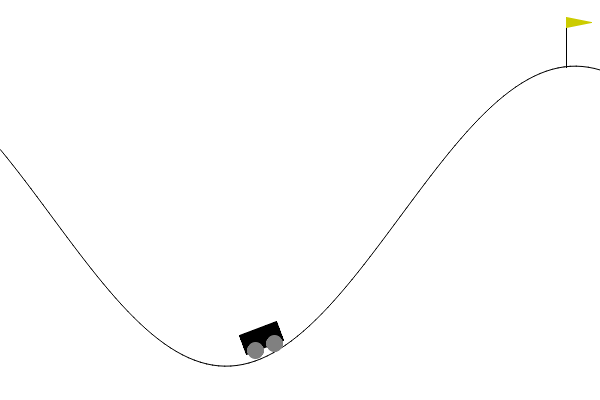

In [17]:

eval_env = gym.make("MountainCar-v0", render_mode="rgb_array")
state = eval_env.reset()[0]
discrete_state = get_discrete_state(state)

frames = []
done = False

while not done:
    action = int(np.argmax(q_table[discrete_state]))
    new_state, reward, done, _, _ = eval_env.step(action)
    frames.append(eval_env.render())
    discrete_state = get_discrete_state(new_state)

eval_env.close()

# Save as GIF — much lighter than jshtml
imageio.mimsave("eval.gif", frames, fps=30)
Image("eval.gif")

## Summary

| Item | Detail |
|---|---|
| Algorithm | Tabular Q-learning (off-policy) |
| Exploration | ε-greedy with exponential decay |
| State space | Continuous → discretised to 20 × 20 grid |
| Episodes | 60 000 |
| Key insight | The car must learn to **build momentum** — the greedy "push right" strategy fails without first going left |

**Limitations of tabular Q-learning here:**  
A 20 × 20 grid is a crude approximation. Finer grids grow memory quadratically, and very fine grids need many more episodes. **DQN** (Deep Q-Network) removes this trade-off by replacing the table with a neural network.

**Next steps:** try increasing `TABLE_SIZE` to `(40, 40)` and observe the effect on convergence speed and final policy quality.